# Zaawansowane programowanie w Pythonie

# prezentuje:

### Numba

---

---

In [142]:
import numpy as np
import matplotlib.pyplot as plt

import numba as nb          # <- o tutaj

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [143]:
#losowanie tablicy


def tablica(n):

    tablica = np.random.randint(0, 2, (n, n))

    for i in range(n):
        for j in range(n):
            if tablica[i][j] == 0:
                tablica[i][j] = -1


    return tablica

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

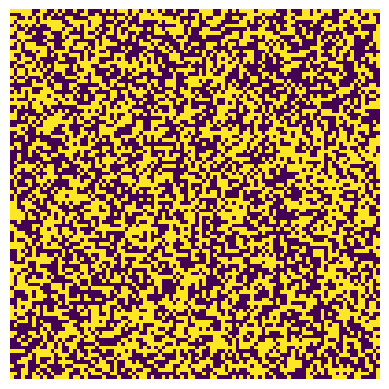

In [144]:
sym0 = tablica(100)

plt.imshow(sym0)
plt.axis('off')

In [145]:
# magnetyzacja = 1/N**2 * suma(s_i)

#energia H = -J*suma_po_sasiadach(s_i*s_j) - B*suma(s_i)

#delta E = 2*s_i * ( J*suma_po_sąsiadach(s_j) + B )

In [146]:
#delta E

def mikrokrok(state, i, j, J, B, beta):
    height, width = state.shape

    count = 0

    for di in range(-1, 2):
        for dj in range(-1, 2):
            if di != 0 and dj != 0:
                ni = (i + di) % height
                nj = (j + dj) % width

                count += state[ni][nj]


    delta = 2 * state[i][j] * (J * count + B)

    if delta < 0:
        return -1 * state[i][j]

    else:
        if np.random.rand() <= np.exp(-1 * beta * delta):
            return -1 * state[i][j]

        else:
            return state[i][j]



In [147]:
#magnetyzacja

def magnetyzacja(state):

    height, width = state.shape

    return np.sum(state)/(height*width)

In [148]:
#energia

def energiaH(state, J, B):
    H = -1 * B * np.sum(state)

    height, width = state.shape

    sumy_sasiadow = 0

    for i in range(height):
        for j in range(width):

            count = -state[i][j]

            for di in range(-1, 2):
                for dj in range(-1, 2):

                    ni = (i + di) % height
                    nj = (j + dj) % width

                    count += state[ni][nj]

            sumy_sasiadow += count


    H += -1 * J * sumy_sasiadow /2

    return H

In [149]:
#def makrokrok(state, J, B, beta):

    #height, width = state.shape

    #next_state = np.zeros_like(state)

    #for i in range(height):
        #for j in range(width):

            #next_state[i][j] = mikrokrok(state, i, j, J, B, beta)


    #return next_state
    

In [150]:
#poprawka


def makrokrok(state, J, B, beta):

    height, width = state.shape

    next_state = state.copy()

    for n in range(height * width):
        
        i = np.random.randint(0, height)
        j = np.random.randint(0, width)

        next_state[i][j] = mikrokrok(state, i, j, J, B, beta)


    return next_state

In [151]:
def symulacja(M, N, J, B, beta):
    state = tablica(N)

    history = [state]
    E_history = [energiaH(state, J, B)]
    M_history = [magnetyzacja(state)]


    for i in range(M):
        state = makrokrok(state, J, B, beta)
        history.append(state)
        E_history.append(energiaH(state, J, B))
        M_history.append(magnetyzacja(state))


    return history, E_history, M_history

In [152]:
stany, energie, magnetyzacje = symulacja(100, 100, 1, 0, 0.6)



In [153]:
def wykres_magn(magn):

    t = []
    for i in range(len(magn)):
        t.append(i)

    plt.plot(t, magn, 'blue')
    plt.xlabel('Numer kroku czasowego')
    plt.ylabel('Magnetyzacja')
    plt.grid(which='both')
    plt.title('Wykres magnetyzacji m(t)')
    plt.show()

In [154]:
def wykres_energ(energ):

    t = []
    for i in range(len(energ)):
        t.append(i)

    plt.plot(t, energ, 'red')
    plt.xlabel('Numer kroku czasowego')
    plt.ylabel('Energia')
    plt.grid(which='both')
    plt.title('Wykres energii całkowitej w czasie')
    plt.show()

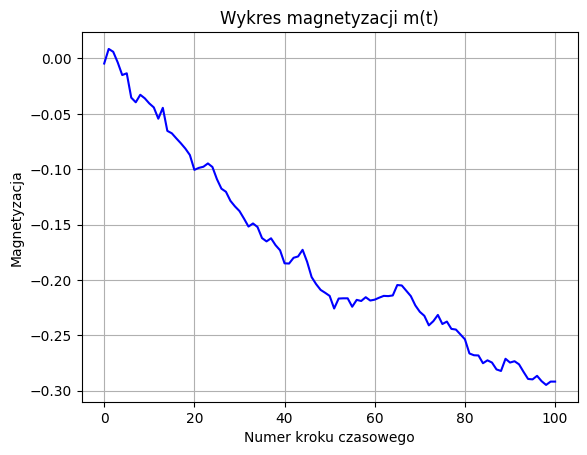

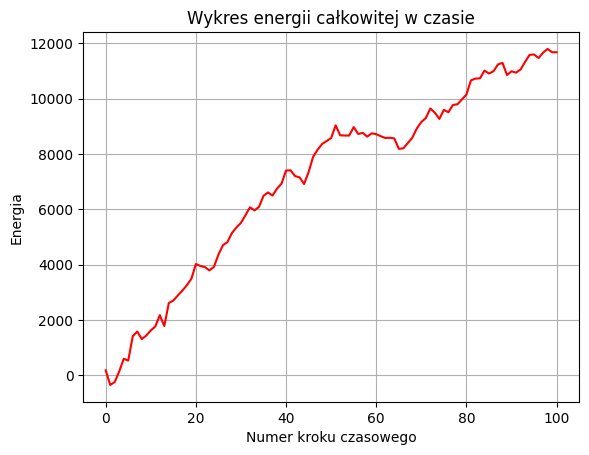

In [155]:
wykres_magn(magnetyzacje)
wykres_energ(energie)

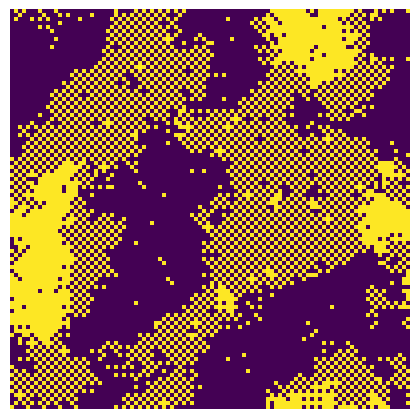

In [156]:
fig = plt.figure(figsize=(4, 4))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.axis('off')

img = plt.imshow(stany[0])

def update(i):
    img.set_data(stany[i])
    return img,

ani = FuncAnimation(fig, update, frames= len(stany), interval= 50, blit=True)
HTML(ani.to_jshtml())

# symulacja wersja zwykła

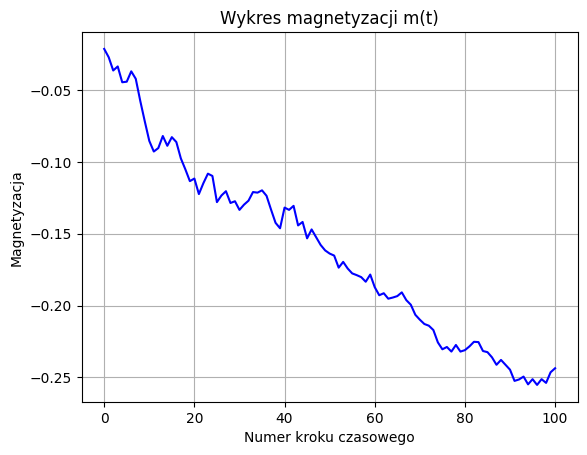

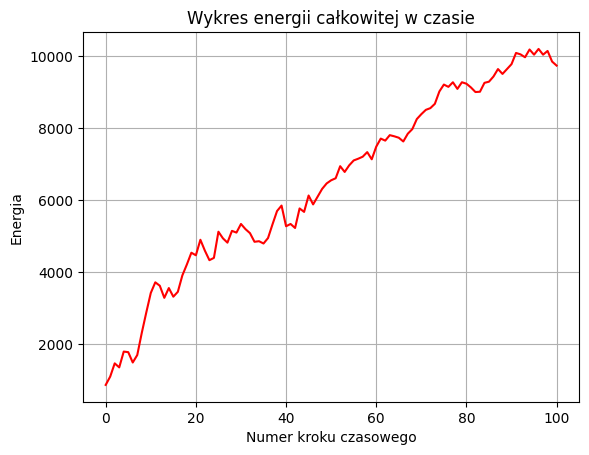

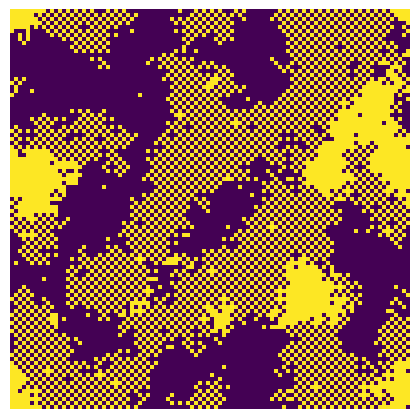

In [157]:
N = 100
beta = 0.6
J = 1
B = 0
M = 100

stany, energie, magnetyzacje = symulacja(M, N, J, B, beta)
    
wykres_magn(magnetyzacje)
wykres_energ(energie)

fig = plt.figure(figsize=(4, 4))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.axis('off')

img = plt.imshow(stany[0])

def update(i):
    img.set_data(stany[i])
    return img,

ani = FuncAnimation(fig, update, frames= len(stany), interval= 50, blit=True)
HTML(ani.to_jshtml())

---
# wersja Numba
---

In [158]:
#losowanie tablicy

@nb.njit
def nb_tablica(n):

    tablica = np.random.randint(0, 2, (n, n))

    for i in range(n):
        for j in range(n):
            if tablica[i][j] == 0:
                tablica[i][j] = -1


    return tablica

In [159]:
#delta E

@nb.njit
def nb_mikrokrok(state, i, j, J, B, beta):
    height, width = state.shape

    count = 0

    for di in range(-1, 2):
        for dj in range(-1, 2):
            #if di != 0 and dj != 0:
            if not (di == 0 and dj == 0):

                ni = (i + di) % height
                nj = (j + dj) % width

                count += state[ni][nj]


    delta = 2 * state[i][j] * (J * count + B)

    if delta < 0:
        return -1 * state[i][j]

    else:
        if np.random.rand() <= np.exp(-1 * beta * delta):
            return -1 * state[i][j]

        else:
            return state[i][j]

In [170]:
#magnetyzacja

@nb.njit
def nb_magnetyzacja(state): 
    
    height, width = state.shape 

    return np.sum(state)/(height*width)

In [161]:
#energia

@nb.njit
def nb_energiaH(state, J, B):
    H = -1 * B * np.sum(state)

    height, width = state.shape

    sumy_sasiadow = 0

    for i in range(height):
        for j in range(width):

            #count = -state[i][j]

            #for di in range(-1, 2):
                #for dj in range(-1, 2):

                    #ni = (i + di) % height
                    #nj = (j + dj) % width

                    #count += state[ni][nj]

            count = 0

            for di in range(-1, 2):
                for dj in range(-1, 2):
                    if not (di == 0 and dj == 0):

                        ni = (i + di) % height
                        nj = (j + dj) % width

                        count += state[ni][nj]

            sumy_sasiadow += count * state[i][j]


    H += -1 * J * sumy_sasiadow / 2

    return H

In [162]:
#@nb.njit
#def nb_makrokrok(state, J, B, beta):

    #height, width = state.shape

    #next_state = np.zeros_like(state)

    #for i in range(height):
        #for j in range(width):

            #next_state[i][j] = nb_mikrokrok(state, i, j, J, B, beta)

####################
    #return next_state

In [163]:
#poprawiony makrokrok

@nb.njit
def nb_makrokrok(state, J, B, beta):

    height, width = state.shape

    next_state = state.copy()

    for n in range(height * width):
        
        i = np.random.randint(0, height)
        j = np.random.randint(0, width)

        #next_state[i][j] = nb_mikrokrok(state, i, j, J, B, beta)
        next_state[i][j] = nb_mikrokrok(next_state, i, j, J, B, beta)


    return next_state


In [164]:
@nb.njit
def nb_symulacja(M, N, J, B, beta):
    state = nb_tablica(N)

    history = [state]
    E_history = [nb_energiaH(state, J, B)]
    M_history = [nb_magnetyzacja(state)]


    for i in range(M):
        state = nb_makrokrok(state, J, B, beta)
        history.append(state)
        E_history.append(nb_energiaH(state, J, B))
        M_history.append(nb_magnetyzacja(state))


    return history, E_history, M_history

# symulacja wersja numba

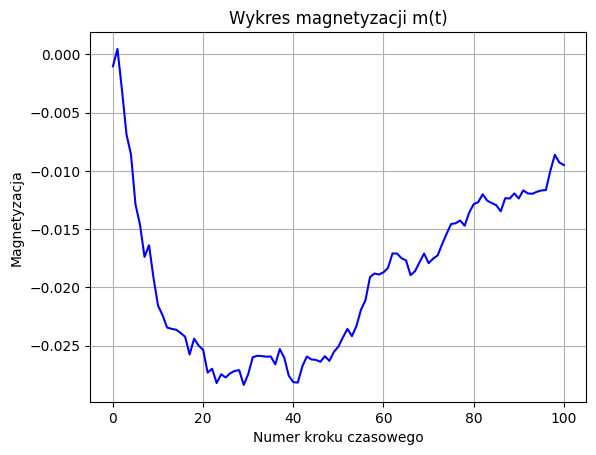

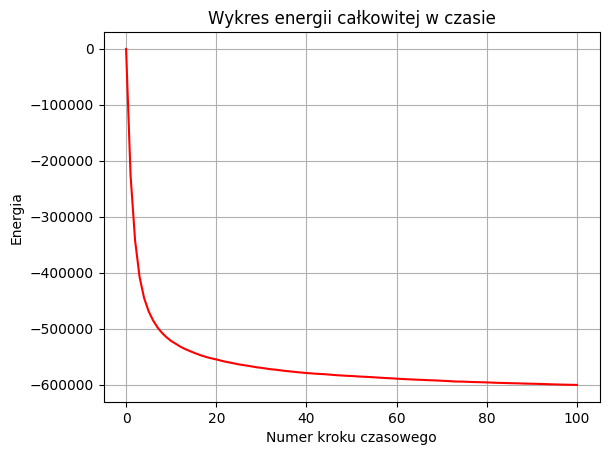

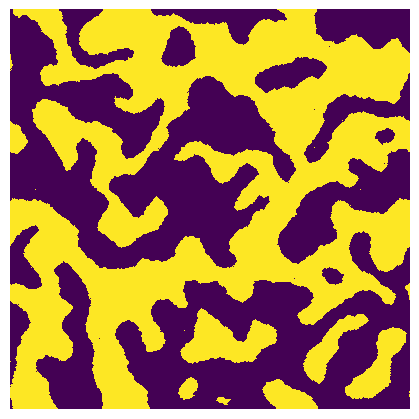

In [169]:
N = 400
beta = 0.6
J = 1
B = 0
M = 100

stany, energie, magnetyzacje = nb_symulacja(M, N, J, B, beta)
    
wykres_magn(magnetyzacje)
wykres_energ(energie)

#plt.plot(np.array(magnetyzacje)/np.array(energie), 'red')
#plt.show()

fig = plt.figure(figsize=(4, 4))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.axis('off')

img = plt.imshow(stany[0])

def update(i):
    img.set_data(stany[i])
    return img,

ani = FuncAnimation(fig, update, frames= len(stany), interval= 50, blit=True)
HTML(ani.to_jshtml())

